**<center>IMPORT</center>**

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, f1_score, accuracy_score

The following code has been generate using "ChatGPT" on "5/7/2026" with the following promt: Can I use !wget for google drive links?




**<center>INSTALL FER-2013 data set</center>**

In [ ]:
!pip install gdown
!gdown "https://drive.google.com/uc?id=1JB9-bIhu7I3jtoYNZi9gSpbfrMtBaVZ4"     #gdown like wget but specificly download from shared google drive link
!unzip fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [ ]:
#Test only
# img = cv2.imread("train/angry/Training_10118481.jpg")
# print(img.shape)
# plt.imshow(img)
# plt.show()

The following code has been generate using "ChatGPT" on "5/9/2026" with the following promt: ok so now after import and download the fer2013, we need make the image to 1 channel gray scale instead of 3 channel gray scale? how to do that?

In [ ]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
    # rotation_range=15,
    # width_shift_range=0.15,
    # height_shift_range=0.15,
    # horizontal_flip=True,
    # zoom_range=0.15,
    # shear_range=0.1,
)
# create training data
train_generator = train_datagen.flow_from_directory(
    "train",
    target_size=(48,48),        #image already 48x48
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',     #read from the directory folder "train" -> each sub-folder in "train" will recognize as a class
    subset='training'             # use the training subset only ( 0.8 of all instances in "train")
)
#links random instance to a batch then when a batch is picked -> perform preprocess then put in to the trainning (i think)

# create validation data
validation_generator = train_datagen.flow_from_directory(
    "train",
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False                         #shuffle when next(...) or model.fit(...) or model.predict(...)
)

#create testing data
test_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
)
test_generator = test_datagen.flow_from_directory(
    "test",
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


(64, 48, 48, 1)
(64, 7)


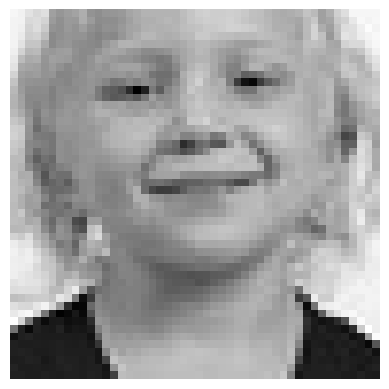

In [ ]:
#Test only!!!!!
images, labels = next(train_generator)    #get the next batch, return a tuple: (images_array, labels_array)
print(images.shape)               #images[64][48][48][1]
print(labels.shape)               #labels[64][7]
plt.imshow(images[0].squeeze(), cmap='gray')  #images[0] = first image in the batch, squeeze() removes dimensions whose size is 1,
#cmap='gray' => display images[0].squeeze() on the color map of gray scale
plt.axis('off')
plt.show()

In [ ]:
#CNN layers
model = keras.models.Sequential([

    keras.layers.Conv2D( 32, (3,3), activation='relu', input_shape=(48,48,1)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.2),

    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),

    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.35),

    keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.4),

    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(7, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.2198 - loss: 2.2524 - val_accuracy: 0.2033 - val_loss: 2.2449
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.3394 - loss: 1.7093 - val_accuracy: 0.3649 - val_loss: 1.6006
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4137 - loss: 1.5212 - val_accuracy: 0.4417 - val_loss: 1.4395
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4528 - loss: 1.4185 - val_accuracy: 0.4484 - val_loss: 1.4402
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4836 - loss: 1.3531 - val_accuracy: 0.4738 - val_loss: 1.3784
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5008 - loss: 1.3078 - val_accuracy: 0.4696 - val_loss: 1.3674
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5190 - loss: 1.2633 - val_accuracy: 0.4935 - val_loss: 1.3029
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5283 - loss: 1.2374 - 

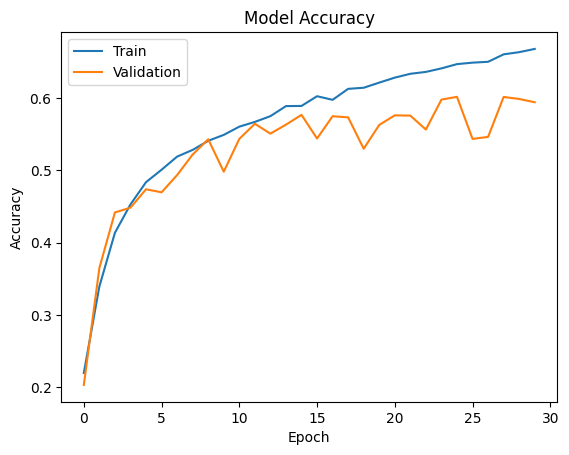

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

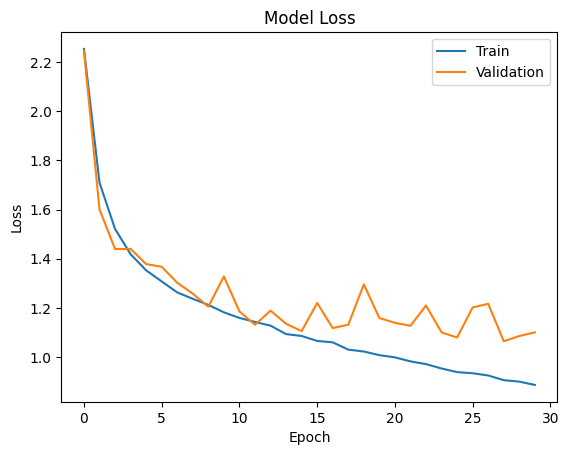

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
class_names = list(train_generator.class_indices.keys())

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


The following code has been generate using "ChatGPT" on "5/14/2026" with the following promt: How to create confusion matrix?

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
[[6.6794294e-01 4.4913199e-02 1.4698800e-01 ... 3.3078074e-02
  7.0427999e-02 3.7728325e-03]
 [5.1953584e-01 5.2095723e-04 1.8699837e-01 ... 9.4838686e-02
  1.3484108e-01 3.5776548e-02]
 [2.9678470e-01 2.3680362e-03 1.3923572e-01 ... 2.6405692e-02
  4.8655307e-01 2.5007369e-02]
 ...
 [2.2768760e-02 4.8908092e-05 5.7723586e-02 ... 2.4310341e-02
  2.8147351e-02 8.6287308e-01]
 [9.4557852e-02 9.2163021e-03 9.4660118e-02 ... 5.0090868e-03
  1.1220379e-02 7.7722889e-01]
 [2.9877988e-03 1.8214065e-05 8.5522741e-02 ... 5.7380337e-05
  1.6628319e-04 9.0781754e-01]]
[0 0 5 ... 6 6 6]


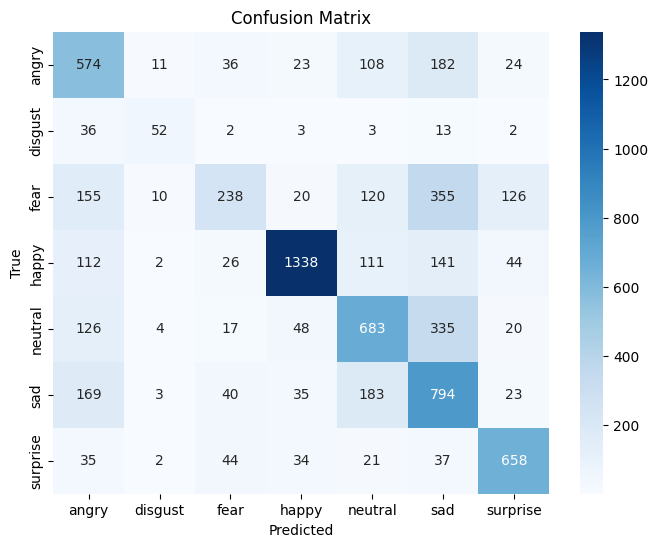

In [ ]:
predictions = model.predict(test_generator)   #change here
print(predictions)
y_pred = np.argmax(predictions, axis=1)
print(y_pred)
y_true = test_generator.classes               #change here
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

The following code has been generate using "ChatGPT" on "5/14/2026" with the following promt: Write me code to calculate F1 score

In [ ]:
print(classification_report(y_true, y_pred))
f1 = f1_score(y_true, y_pred, average='weighted')

print("F1-score:", f1)

print(f"True accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           0       0.48      0.60      0.53       958
           1       0.62      0.47      0.53       111
           2       0.59      0.23      0.33      1024
           3       0.89      0.75      0.82      1774
           4       0.56      0.55      0.55      1233
           5       0.43      0.64      0.51      1247
           6       0.73      0.79      0.76       831

    accuracy                           0.60      7178
   macro avg       0.61      0.58      0.58      7178
weighted avg       0.63      0.60      0.60      7178

F1-score: 0.6008958343226181
True accuracy: 0.6042
              precision    recall  f1-score   support

       angry       0.48      0.60      0.53       958
     disgust       0.62      0.47      0.53       111
        fear       0.59      0.23      0.33      1024
       happy       0.89      0.75      0.82      1774
     neutral       0.56      0.55      0.55      1233
         sad       0.43    